to minimise the gap between variable and reducing the significance of large value columns we use-
This is Standardization , which is a technique to centralise the values to 0 with standard deviation =1 . it uses formula - Z= (x_value-u_mean)/standard_deviation.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Social_Network_Ads.csv")
df.sample(10)

,User ID,Gender,Age,EstimatedSalary,Purchased
255,15750056,Female,52,90000,1
324,15575247,Female,48,131000,1
120,15811613,Female,36,75000,0
28,15744529,Male,29,43000,0
42,15772798,Male,35,108000,0
387,15627220,Male,39,71000,0
364,15654456,Male,42,104000,1
139,15741094,Male,19,25000,0
153,15619087,Female,36,50000,0
311,15622585,Male,39,96000,1


In [3]:
df=df.drop(columns=["User ID","Gender"])
df.sample(10)

,Age,EstimatedSalary,Purchased
44,28,84000,0
260,35,77000,0
222,37,144000,1
144,34,25000,0
149,20,74000,0
3,27,57000,0
193,19,70000,0
251,37,52000,0
152,31,76000,0
285,37,93000,1


In [5]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test= train_test_split(df.drop(columns=["Purchased"]),df["Purchased"],test_size=0.2,random_state=0)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((320, 2), (80, 2), (320,), (80,))

In [6]:
# Standardization of the data using StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train)

x_train_scaled=scaler.transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [7]:
scaler.mean_

array([3.8218750e+01, 6.9928125e+04])

In [8]:
x_train

,Age,EstimatedSalary
336,58,144000
64,59,83000
55,24,55000
106,26,35000
300,58,38000
...,...,...
323,48,30000
192,29,43000
117,36,52000
47,27,54000


In [9]:
x_train_scaled

array([[ 1.92295008e+00,  2.14601566e+00],
       [ 2.02016082e+00,  3.78719297e-01],
       [-1.38221530e+00, -4.32498705e-01],
       [-1.18779381e+00, -1.01194013e+00],
       [ 1.92295008e+00, -9.25023920e-01],
       [ 3.67578135e-01,  2.91803083e-01],
       [ 1.73156642e-01,  1.46942725e-01],
       [ 2.02016082e+00,  1.74040666e+00],
       [ 7.56421121e-01, -8.38107706e-01],
       [ 2.70367388e-01, -2.87638347e-01],
       [ 3.67578135e-01, -1.71750061e-01],
       [-1.18475597e-01,  2.20395980e+00],
       [-1.47942605e+00, -6.35303205e-01],
       [-1.28500455e+00, -1.06988428e+00],
       [-1.38221530e+00,  4.07691369e-01],
       [-1.09058306e+00,  7.55356227e-01],
       [-1.47942605e+00, -2.00722133e-01],
       [ 9.50842613e-01, -1.06988428e+00],
       [ 9.50842613e-01,  5.81523798e-01],
       [ 3.67578135e-01,  9.87132798e-01],
       [ 5.61999628e-01, -8.96051849e-01],
       [-6.04529329e-01,  1.45068594e+00],
       [-2.12648508e-02, -5.77359062e-01],
       [-6.

In [10]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)

In [11]:
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)
x_test_scaled

,Age,EstimatedSalary
0,-0.798951,0.494608
1,-0.021265,-0.577359
2,-0.312897,0.146943
3,-0.798951,0.262831
4,-0.312897,-0.577359
...,...,...
75,-1.965480,0.349747
76,0.367578,0.262831
77,0.173157,-0.287638
78,1.436896,-1.040912


In [15]:
np.round(x_train.describe(),3)

,Age,EstimatedSalary
count,320.000,320.000
mean,38.219,69928.125
std,10.303,34570.057
min,18.000,15000.000
25%,30.000,43000.000
50%,38.000,69500.000
75%,46.000,88000.000
max,60.000,150000.000


In [16]:
np.round(x_train_scaled.describe(), 3)

,Age,EstimatedSalary
count,320.000,320.000
mean,0.000,0.000
std,1.002,1.002
min,-1.965,-1.591
25%,-0.799,-0.780
50%,-0.021,-0.012
75%,0.756,0.524
max,2.117,2.320


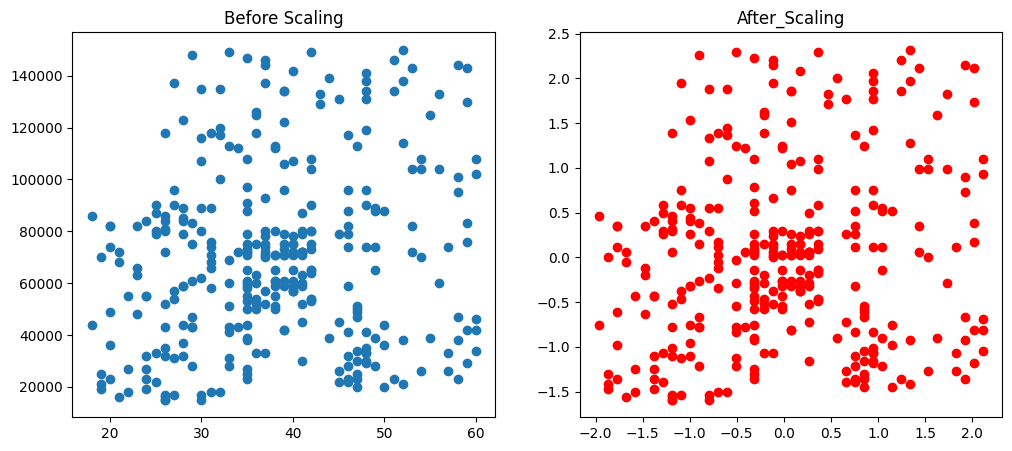

In [18]:
# Effect of Scaling 

fig ,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.scatter(x_train["Age"],x_train["EstimatedSalary"])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled["Age"],x_train_scaled["EstimatedSalary"],color="red")
ax2.set_title("After_Scaling")
plt.show()

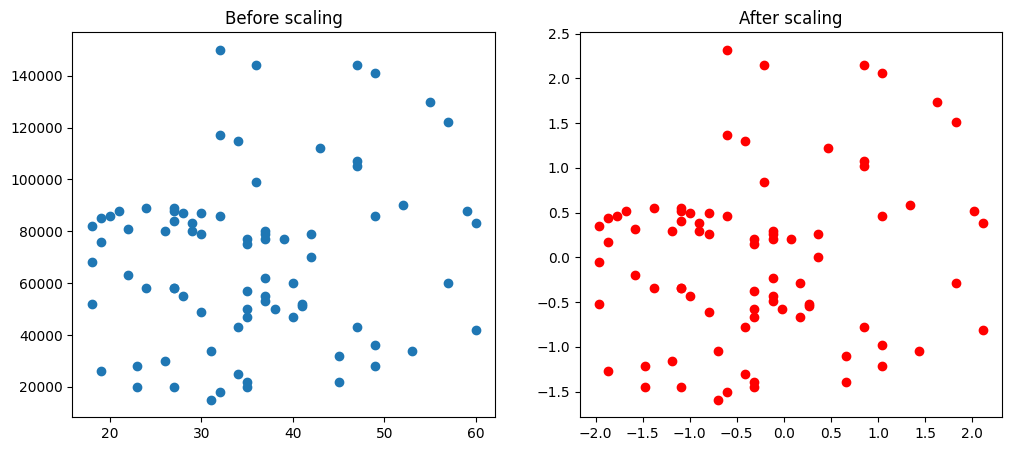

In [19]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))
ax1.scatter(x_test["Age"],x_test["EstimatedSalary"])
ax1.set_title("Before scaling")
ax2.scatter(x_test_scaled["Age"],x_test_scaled["EstimatedSalary"],color='red')
ax2.set_title("After scaling")
plt.show()

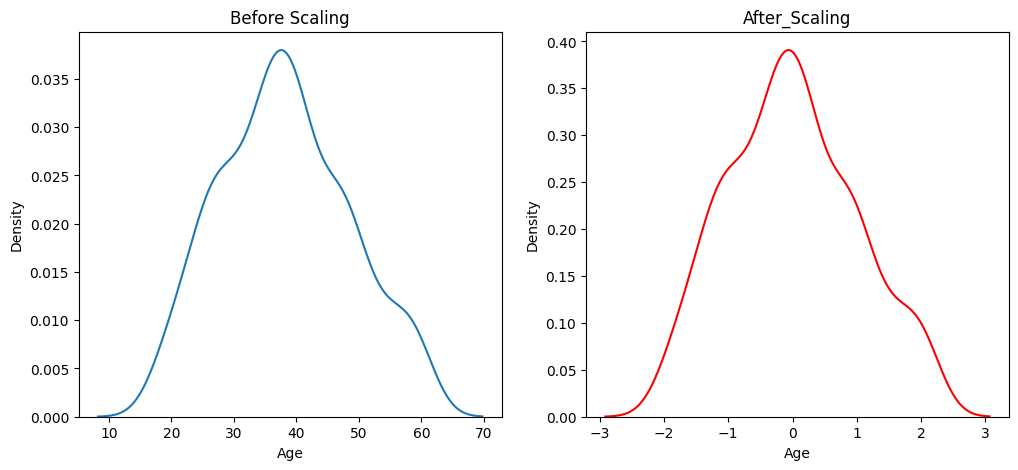

In [21]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

sns.kdeplot(x_train["Age"],ax=ax1,label="Before Scaling")
ax1.set_title("Before Scaling")

sns.kdeplot(x_train_scaled["Age"],ax=ax2,label="After_Scaling",color="red")
ax2.set_title("After_Scaling")

plt.show()


In [22]:
# Why Scaling is important?

from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()
lr_scaled=LogisticRegression()

lr.fit(x_train,y_train)
lr_scaled.fit(x_train_scaled,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [24]:
y_pred=lr.predict(x_test)
y_pred_scaled=lr_scaled.predict(x_test_scaled)

In [25]:
from sklearn.metrics import accuracy_score

print("Accuracy of Logistic Regression without Scaling:",accuracy_score(y_test,y_pred))
print("Accuracy of Logirstic Regression with Scaling:",accuracy_score(y_test,y_pred_scaled))


Accuracy of Logistic Regression without Scaling: 0.9125
Accuracy of Logirstic Regression with Scaling: 0.925


In [27]:
from sklearn.tree import DecisionTreeClassifier

dt=DecisionTreeClassifier()
dt_scaled=DecisionTreeClassifier()

dt.fit(x_train,y_train)
dt_scaled.fit(x_train_scaled,y_train)
pred_dt=dt.predict(x_test)
pred_dt_scaled=dt_scaled.predict(x_test_scaled)

print("Accuracy of Decision Tree Classifier without Scaling:",accuracy_score(y_test,pred_dt))
print("Accuracy of Decision Tree Classifier with Scaling:",accuracy_score(y_test,pred_dt_scaled))


Accuracy of Decision Tree Classifier without Scaling: 0.9125
Accuracy of Decision Tree Classifier with Scaling: 0.9125


In [30]:
# Effect of outliers 

df=pd.concat([df,pd.DataFrame({"Age":[5,90,95],"EstimatedSalary":[1000,25000,350000],'Purchased':[0,1,1]})],ignore_index=True)
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
398,36,33000,0
399,49,36000,1
400,5,1000,0
401,90,25000,1


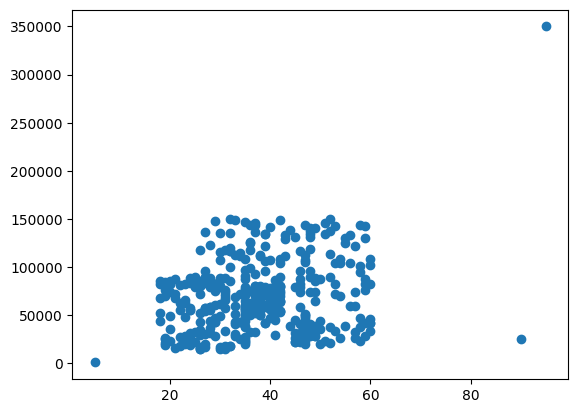

In [31]:
plt.scatter(df["Age"],df["EstimatedSalary"])

In [ ]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=["Purchased"]),df["Purchased"],test_size=0.2,random_state=0)

x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()
slr=LogisticRegression()

lr.fit(x_train,y_train)
slr.fit(x_train_scaled,y_train)

lr_pred=lr.predict(x_test)
slr_pred=slr.predict(x_test_scaled)

In [35]:
print("Accuracy of Logistic Regression without Scaling:",accuracy_score(y_test,lr_pred))
print("Accuracy of Logistic Regression with Scaling:",accuracy_score(y_test,slr_pred))

Accuracy of Logistic Regression without Scaling: 0.8888888888888888
Accuracy of Logistic Regression with Scaling: 0.8765432098765432


In [39]:
x_train_scaled=pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled=pd.DataFrame(x_test_scaled,columns=x_test.columns)

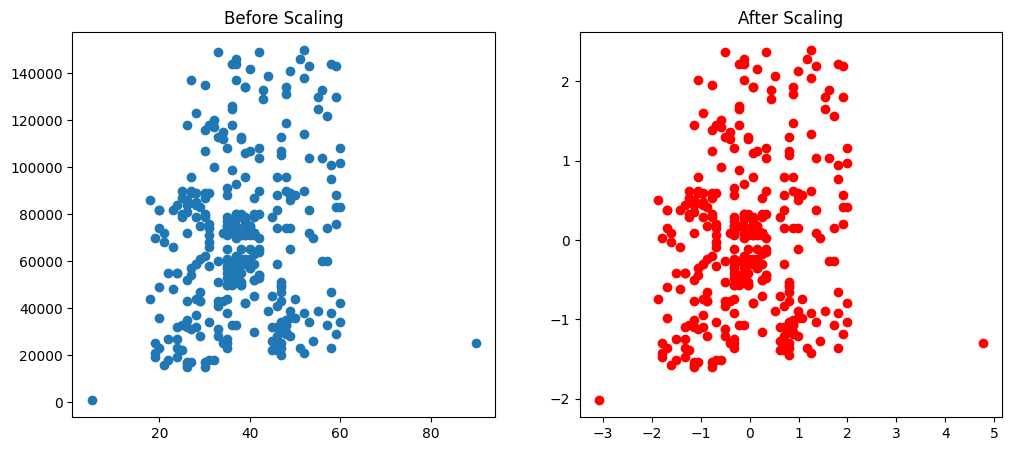

In [40]:
fig,(ax1,ax2)=plt.subplots(ncols=2,figsize=(12,5))

ax1.set_title("Before Scaling")
ax1.scatter(x_train["Age"],x_train["EstimatedSalary"])

ax2.set_title("After Scaling")
ax2.scatter(x_train_scaled["Age"],x_train_scaled["EstimatedSalary"],color="red")
plt.show()